In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import os

In [ ]:
# Set paths for your training and validation data
train_dir = r'C:/Users/ACER/Desktop/IS/food_recog/data/train'  
valid_dir = r'C:/Users/ACER/Desktop/IS/food_recog/data/valid'  


input_size = (224, 224)  # VGG16 input size
num_classes = 3  


In [9]:
# Data Augmentation for training and validation sets
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    brightness_range=[0.8, 1.2]
)

valid_datagen = ImageDataGenerator(rescale=1./255)  # Only rescaling for validation set


In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=input_size,
    batch_size=32,
    class_mode='categorical'
)

Found 266 images belonging to 3 classes.


In [11]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=input_size,
    batch_size=32,
    class_mode='categorical'
)

Found 194 images belonging to 3 classes.


In [12]:
# Load pre-trained VGG16 model without the top (classification) layer
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the base model to avoid retraining them
base_model.trainable = False


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [13]:
# Build the custom model with VGG16 as base
model = models.Sequential([
    base_model,  # Add the VGG16 base model
    layers.GlobalAveragePooling2D(),  # Pool the output of VGG16
    layers.BatchNormalization(),  # Batch Normalization to improve performance
    layers.Dense(128, activation='relu'),  # Fully connected layer
    layers.Dropout(0.5),  # Dropout to avoid overfitting
    layers.Dense(num_classes, activation='softmax')  # Output layer with softmax for classification
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Setup early stopping and learning rate scheduler
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

In [14]:
# Train the model
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=valid_generator,
    callbacks=[early_stopping, lr_scheduler]
)

# Save the trained model
model.save('food_recognition_model.h5')


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 32s 4s/step - accuracy: 0.3965 - loss: 1.3348 - val_accuracy: 0.6392 - val_loss: 0.8157 - learning_rate: 0.0010
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 30s 3s/step - accuracy: 0.6778 - loss: 0.7026 - val_accuracy: 0.6392 - val_loss: 0.7472 - learning_rate: 0.0010
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.7877 - loss: 0.5794 - val_accuracy: 0.6495 - val_loss: 0.7075 - learning_rate: 0.0010
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 31s 4s/step - accuracy: 0.7984 - loss: 0.4204 - val_accuracy: 0.6701 - val_loss: 0.6896 - learning_rate: 0.0010
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.8761 - loss: 0.3675 - val_accuracy: 0.6753 - val_loss: 0.6670 - learning_rate: 0.0010
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 4s/step - accuracy: 0.8880 - loss: 0.2937 - val_accuracy: 0.7113 - val_loss: 0.6361 - learning_rate: 0.0010
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 29s 3s/step - accuracy: 0.9120 - loss: 0.2173 - val_accuracy: 0.7423 - val_l

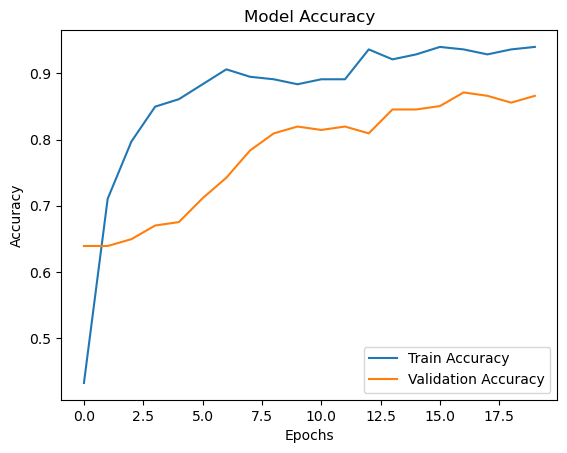

In [15]:
# Optionally, plot training history (optional)
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()



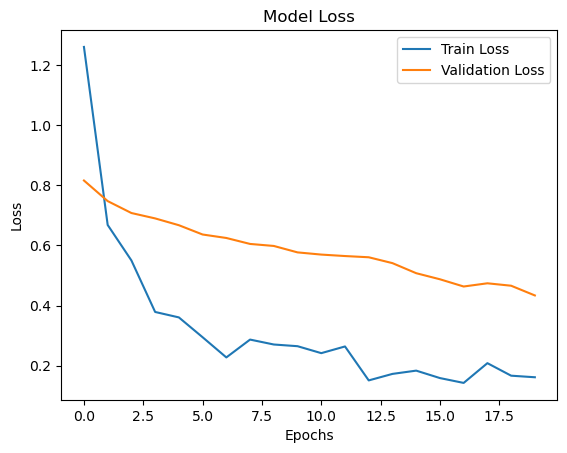

In [16]:
# Plot training & validation loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()

In [26]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import cv2
import os

# Load the trained model
model = tf.keras.models.load_model('food_recognition_model.h5')

# Define the class labels (same order as used in training)
class_labels = ['dessert', 'meal', 'drinks']  # Replace with your actual class labels if different

# Function to preprocess and predict on a single image
def predict_image(image_path):
    # Load the image with the same size used during training
    img = load_img(image_path, target_size=(224, 224))  # Resize to model input size
    img_array = img_to_array(img)  # Convert the image to a numpy array
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
    img_array /= 255.0  # Normalize the image

    # Make predictions
    predictions = model.predict(img_array)
    predicted_class = np.argmax(predictions[0])  # Get the index of the highest score
    confidence = predictions[0][predicted_class]  # Get the confidence score

    return class_labels[predicted_class], confidence

# Function to display the image with predictions
def display_prediction(image_path):
    # Predict the class and confidence
    predicted_class, confidence = predict_image(image_path)

    # Load the original image using OpenCV
    img = cv2.imread(image_path)

    # Resize the image for display
    display_img = cv2.resize(img, (600, 400))

    # Overlay the prediction text
    label = f"{predicted_class}: {confidence:.2f}"
    cv2.putText(display_img, label, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    # Display the image in a window
    cv2.imshow("Prediction", display_img)

    # Wait for a key press to close the window
    cv2.waitKey(0)
    cv2.destroyAllWindows()


# Test the model with a sample image
test_image_path = r'data/valid/meal/meal_original_IMG_4434.jpg_744a322c-7238-4e49-a401-a5f51707c5fe.jpg'  # Replace with your test image path
display_prediction(test_image_path)

print(f"Predicted Class: {predicted_class}")
print(f"Confidence: {confidence:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 313ms/step
Predicted Class: meal
Confidence: 0.85


In [28]:
from tensorflow.keras.models import load_model
model = load_model('food_recognition_model.h5')

In [29]:
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1.0/255.0)

train_generator = train_datagen.flow_from_directory(
    'data/train',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    'data/valid',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 266 images belonging to 3 classes.
Found 194 images belonging to 3 classes.


In [ ]:
for layer in model.layers[-20:]:  
    layer.trainable = True

# Recompile the model with a smaller learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    callbacks=[lr_scheduler]
)

Epoch 1/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 95s 10s/step - accuracy: 0.9500 - loss: 0.1242 - val_accuracy: 0.9227 - val_loss: 0.3473 - learning_rate: 1.0000e-05
Epoch 2/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 82s 9s/step - accuracy: 0.9676 - loss: 0.0919 - val_accuracy: 0.9124 - val_loss: 0.3378 - learning_rate: 1.0000e-05
Epoch 3/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 83s 9s/step - accuracy: 0.9458 - loss: 0.1290 - val_accuracy: 0.9227 - val_loss: 0.2960 - learning_rate: 1.0000e-05
Epoch 4/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 90s 10s/step - accuracy: 0.9709 - loss: 0.0887 - val_accuracy: 0.9433 - val_loss: 0.2736 - learning_rate: 1.0000e-05
Epoch 5/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 90s 10s/step - accuracy: 0.9706 - loss: 0.0921 - val_accuracy: 0.9381 - val_loss: 0.2283 - learning_rate: 1.0000e-05
Epoch 6/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 85s 9s/step - accuracy: 0.9544 - loss: 0.1142 - val_accuracy: 0.9330 - val_loss: 0.2228 - learning_rate: 1.0000e-05
Epoch 7/10
9/9 ━━━━━━━━━━━━━━━━━━━━ 88s 10s/step - accuracy: 0.9741 - loss: 0.0572 - 

In [34]:
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_generator = test_datagen.flow_from_directory(
    'data/test',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.2f}")


Found 15 images belonging to 3 classes.
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.9333 - loss: 0.2101
Test Accuracy: 0.93


In [35]:
model.save('updated_food_recognition_model.h5')